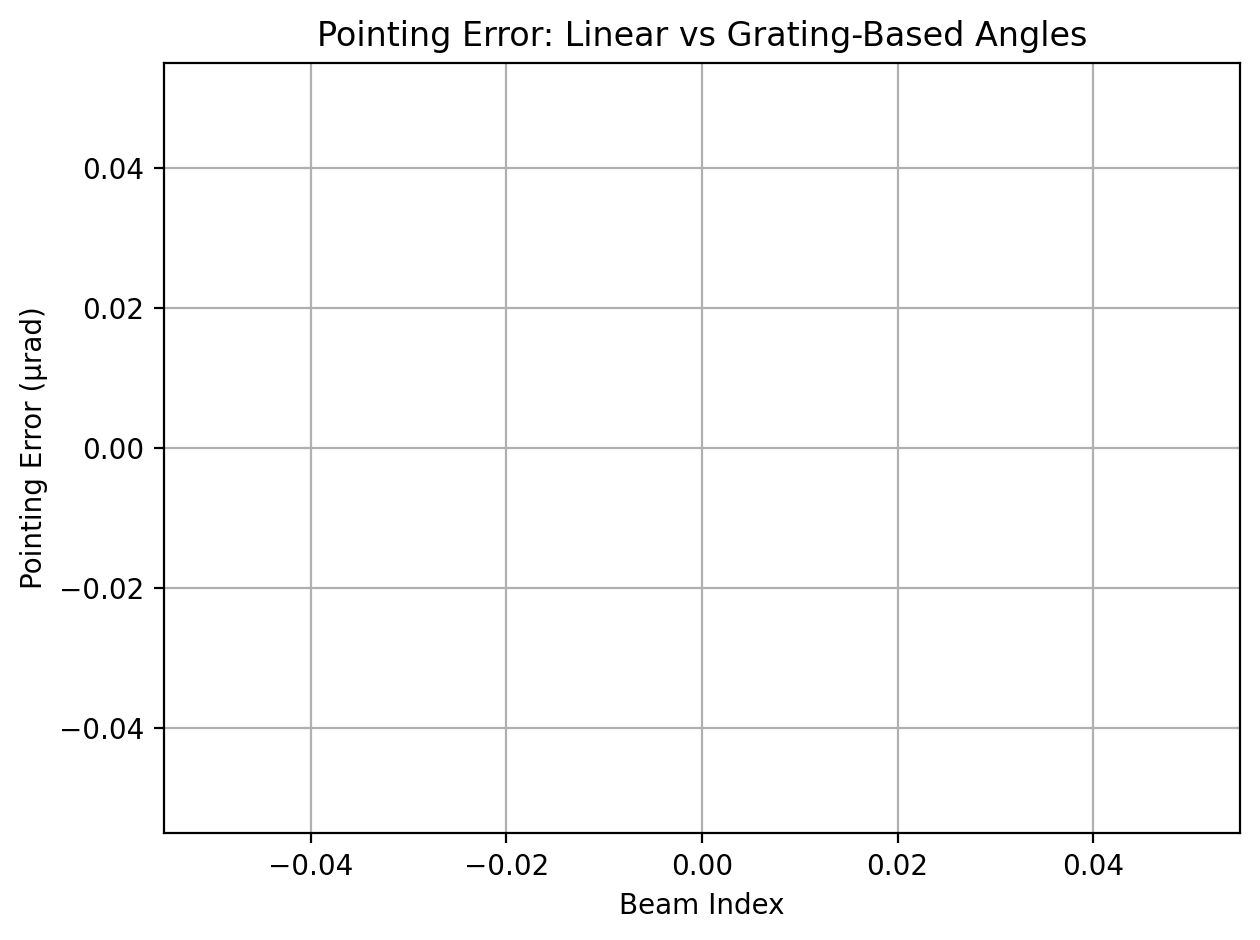

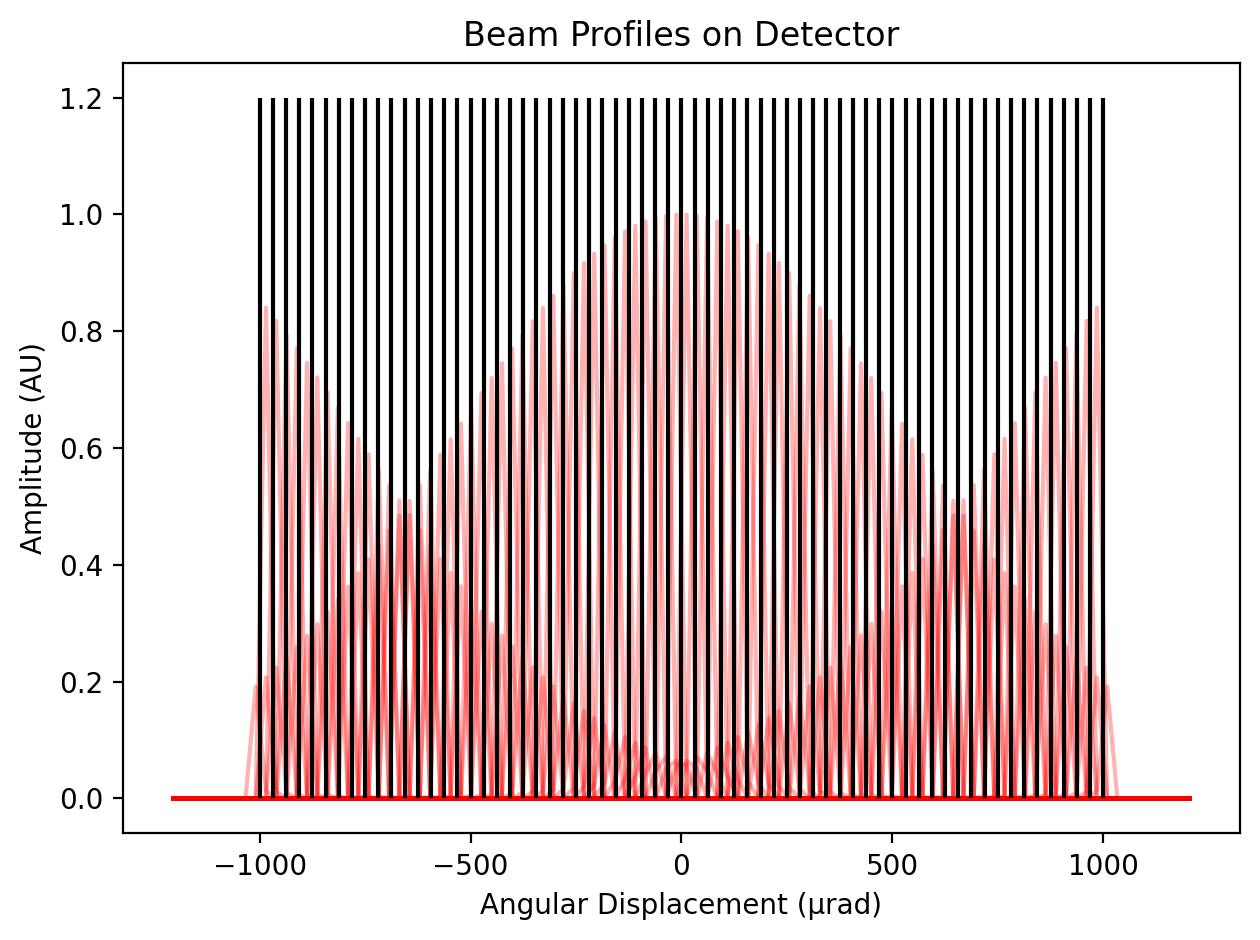

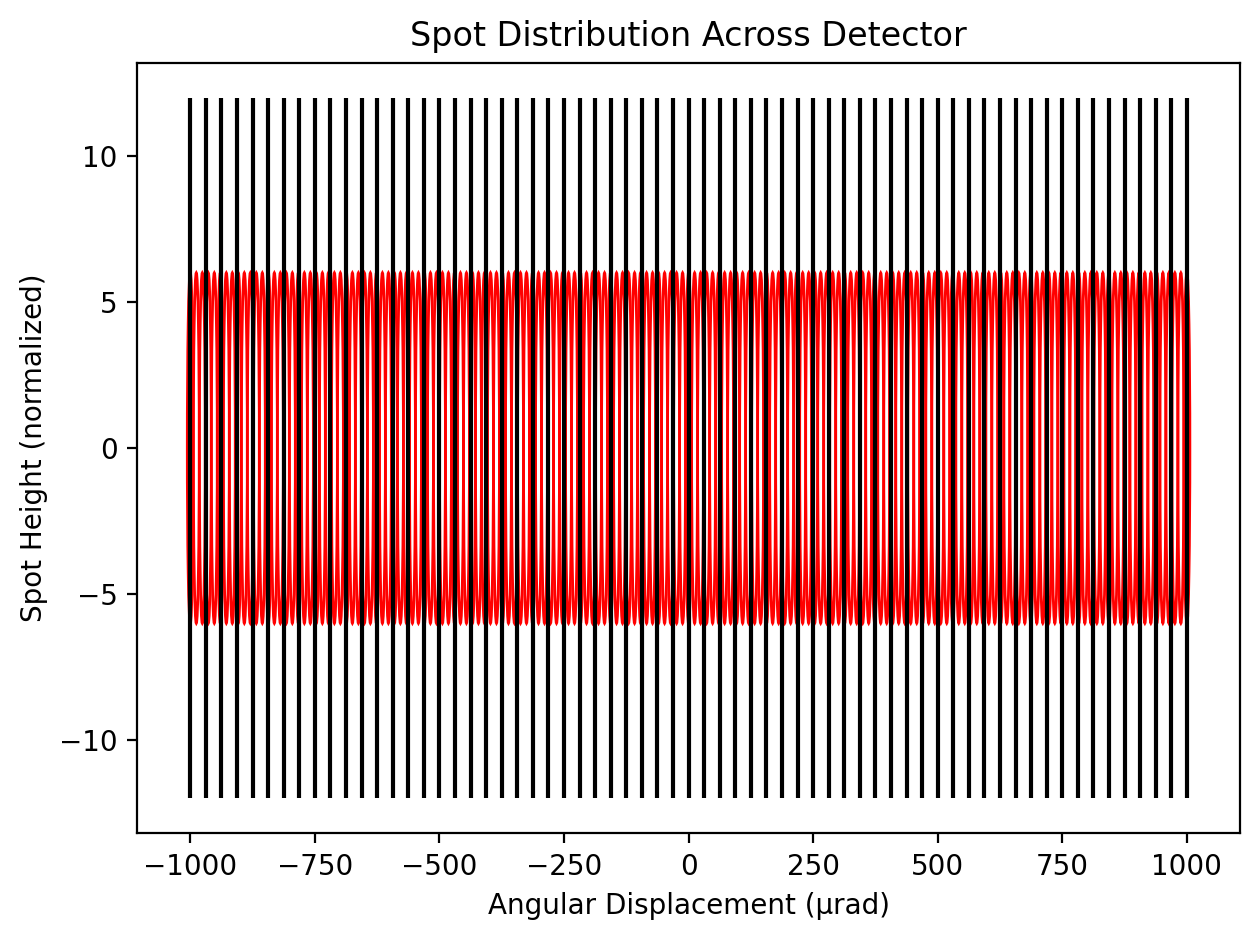

In [26]:
"""
Created on Mon Jun 30 16:14:14 2025

@author: gbclarke
@revised: DK Rai
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Define constant
C = 299792458  # speed of light in meters per second

def _compute_geometry(lpmm, gsd, alt_km, swath_km, wl_nm, wl_span_nm):
    """
    Computes geometric and optical parameters for the grating system.
    
    Parameters:
    - lpmm: Lines per mm on the diffraction grating
    - gsd: Ground sampling distance (m)
    - alt_km: Altitude of the platform (km)
    - swath_km: Swath width on the ground (km)
    - wl_nm: Central wavelength (nm)
    - wl_span_nm: Total wavelength sweep range (nm)

    Returns:
    - fov_rad: Field of view in radians
    - line_spacing: Grating line spacing in meters
    - num_steps: Number of discrete angular beam steps
    - dwl: Wavelength step between ground spots
    - aoi_rad: Optimal angle of incidence on the grating (rad)
    - dispersion_mrad_nm: Angular dispersion in mrad/nm
    - bexpansion: Required beam expander ratio
    - div_urad: Far-field divergence in microradians
    - beam_out_mm: Output beam diameter in mm
    - beam_on_grating_mm: Beam footprint on the grating in mm
    """
    fov_rad = swath_km / alt_km                     # Field of view in rad
    line_spacing = 1 / (lpmm * 1000)                # Grating line spacing in m
    num_steps = int(np.ceil(swath_km * 1000 / gsd)) # Number of discrete angular beam steps. Also ceil outputs the higher number for the fraction, 166 without and 167 with ceil
    dwl = wl_span_nm / num_steps                    # Wavelength step between ground spots in nm

    # Sweep incident angles to find one that minimizes the diffraction error
    Number = 1000                                                # number of points between 0 and π/2.
    angles = np.linspace(0, np.pi / 2, Number)                   # points between 0 and π/2
    a1 = np.arcsin(wl_nm * 1e-9 / line_spacing - np.sin(angles)) # outputs deviation from first order diffraction condition, λ/d. Also true for tranmission geometry
    aoi_error = np.abs(a1 - angles)                              # gets absolute values of deviations
    min_index = np.argmin(aoi_error)                             # argmin returns minimum output
    aoi_rad = angles[min_index]                                  # Optimal angle of incidence on the grating in rad corresponding to minimum diffraction error

    # Dispersion calculated from angle difference per nm at optimal AOI
    a1_at_aoi = np.arcsin(wl_nm * 1e-9 / line_spacing - np.sin(aoi_rad))
    a2_at_aoi = np.arcsin((wl_nm + dwl) * 1e-9 / line_spacing - np.sin(aoi_rad))
    dispersion_mrad_nm = np.abs(a1_at_aoi - a2_at_aoi) * 1000 / dwl

    # Beam expansion required to map the angular dispersion to the field of view
    bexpansion = dispersion_mrad_nm * wl_span_nm / fov_rad / 1000

    # Beam divergence in far field (µrad)
    div_urad = gsd / 2.355 * 4 / (alt_km * 1000) * 1e6 # not sure what the 2.355 is for

    # Output beam diameter (diffraction-limited) and beam size at grating
    beam_out_mm = 2 * wl_nm * 1e-9 / (np.pi * div_urad / 2 * 1e-6) * 1e3
    beam_on_grating_mm = beam_out_mm / bexpansion

    return (fov_rad, line_spacing, num_steps, dwl, aoi_rad,
            dispersion_mrad_nm, bexpansion, div_urad, beam_out_mm,
            beam_on_grating_mm)

def _compute_pointing_error(num_steps, swath_km, alt_km, wl_nm, wl_span_nm,
                            line_spacing, aoi_rad, bexpansion):
    """
    Computes pointing error between linearly interpolated angles and
    those derived from grating frequency sweep.
    
    Returns:
    - angle_linear: Ideal pointing angle (linear scan)
    - wavelengths_nm: Wavelengths corresponding to beam steps
    - angle_grating: Real grating angles from wavelength sweep
    - pointing_error_urad: Error in angular pointing (µrad)
    """
    idx = np.arange(num_steps)
    angle_linear = idx / (num_steps - 1) * swath_km / alt_km

    # Define frequency sweep and convert to wavelength steps
    wl_start = wl_nm - wl_span_nm / 2
    wl_end = wl_nm + wl_span_nm / 2
    f_start = C / (wl_start * 1e-9)
    f_end = C / (wl_end * 1e-9)
    delta_f = (f_start - f_end) / (num_steps - 1)
    freqs = f_start - delta_f * idx
    wavelengths_nm = C / freqs * 1e9

    # Convert wavelengths to angles using grating equation
    a0 = np.arcsin(wavelengths_nm[0] * 1e-9 / line_spacing - np.sin(aoi_rad))
    angles = np.arcsin(wavelengths_nm * 1e-9 / line_spacing - np.sin(aoi_rad))
    angle_grating = -(a0 - angles) / bexpansion
    pointing_error_urad = (angle_linear - angle_grating) * 1e6

    return angle_linear, wavelengths_nm, angle_grating, pointing_error_urad

def plot_pointing_error(pointing_error_urad):
    """
    Plot the angular pointing error between ideal and grating-derived beams.
    """
    plt.figure(dpi=200)
    plt.plot(pointing_error_urad, 'm')
    plt.xlabel("Beam Index")
    plt.ylabel("Pointing Error (µrad)")
    plt.title("Pointing Error: Linear vs Grating-Based Angles")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_detector_response(angle_linear, angle_grating, div_urad,
                           swath_km, alt_km, n_pixels, num_steps):
    """
    Plot the Gaussian beam profiles from both linear and grating steps
    across the detector field.
    """
    plt.figure(dpi=200)
    x = np.linspace(angle_linear[0] - 10 * div_urad * 1e-6,
                    angle_linear[-1] + 10 * div_urad * 1e-6, 100) * 1e6  # 

    for i in range(num_steps):
        g1 = np.exp(-2 * (x - angle_linear[i] * 1e6)**2 / (div_urad / 2)**2)
        g2 = np.exp(-2 * (x - angle_grating[i] * 1e6)**2 / (div_urad / 2)**2)
        plt.plot(x - swath_km / alt_km / 2 * 1e6, g1, 'r', alpha=0.3)
        plt.plot(x - swath_km / alt_km / 2 * 1e6, g2, 'b', alpha=0.3)

    # Add pixel edges
    pixel_edges = np.linspace(0, n_pixels - 2, n_pixels + 1) * swath_km / alt_km / (n_pixels - 2)
    plt.vlines(pixel_edges * 1e6 - swath_km / alt_km / 2 * 1e6, 0, 1.2, colors='k')
    plt.xlabel("Angular Displacement (µrad)")
    plt.ylabel("Amplitude (AU)")
    plt.title("Beam Profiles on Detector")
    plt.tight_layout()
    plt.show()

def plot_spot_distribution(angle_linear, angle_grating, gsd, alt_km,
                           swath_km, n_pixels, num_steps):
    """
    Show footprint (spots) of each beam on the angular domain.
    """
    fig, ax = plt.subplots(dpi=200)
    pixel_edges = np.linspace(0, n_pixels - 2, n_pixels + 1) * swath_km / alt_km / (n_pixels - 2)
    ax.vlines(pixel_edges * 1e6 - swath_km / alt_km / 2 * 1e6,
              -gsd / (alt_km / 1000), gsd / (alt_km / 1000), colors='k')

    for i in range(num_steps):
        for angle, color in [(angle_linear[i], 'r'), (angle_grating[i], 'b')]:
            ellipse = patches.Ellipse((angle * 1e6 - swath_km / alt_km / 2 * 1e6, 0),
                                      gsd / (alt_km / 1000), gsd / (alt_km / 1000),
                                      fill=False, edgecolor=color, linewidth=1)
            ax.add_patch(ellipse)

    ax.set_xlabel("Angular Displacement (µrad)")
    ax.set_ylabel("Spot Height (normalized)")
    ax.set_title("Spot Distribution Across Detector")
    plt.tight_layout()
    plt.show()

def setup_params(mode='Space'):
    """
    Define system parameters for either Space or Aircraft configuration.
    """
    return {
        'lpmm': 1500,
        'gsd': 6 if mode == 'Space' else 0.233,
        'h': 500 if mode == 'Space' else 4.5,
        'd': 1 if mode == 'Space' else 0.233 * (256 - 1) / 1000,
        'wl': 1040,
        'wl_span': 13.074,
        'n_pixels': 64 if mode == 'Space' else 8
    }

def run_grating_calc(params):
    """
    Main routine to compute geometry, pointing, and display results.
    """
    # Unpack parameters
    lpmm = params['lpmm']
    gsd = params['gsd']
    alt_km = params['h']
    swath_km = params['d']
    wl_nm = params['wl']
    wl_span_nm = params['wl_span']
    n_pixels = params['n_pixels']

    # Geometry calculations
    (fov_rad, line_spacing, num_steps, dwl, aoi_rad,
     dispersion_mrad_nm, bexpansion, div_urad, beam_out_mm,
     beam_on_grating_mm) = _compute_geometry(lpmm, gsd, alt_km, swath_km, wl_nm, wl_span_nm)

    # Pointing calculations
    (angle_linear, wavelengths_nm, angle_grating,
     pointing_error_urad) = _compute_pointing_error(num_steps, swath_km, alt_km, wl_nm, wl_span_nm,
                                                    line_spacing, aoi_rad, bexpansion)

    # Plot all results
    plot_pointing_error(pointing_error_urad)
    plot_detector_response(angle_linear, angle_grating, div_urad,
                           swath_km, alt_km, n_pixels, num_steps)
    plot_spot_distribution(angle_linear, angle_grating, gsd, alt_km,
                           swath_km, n_pixels, num_steps)
    
if __name__ == "__main__":
    params = setup_params('Space')  # Use 'Aircraft' for airborne mode and 'Space' for SC mode.
    run_grating_calc(params)

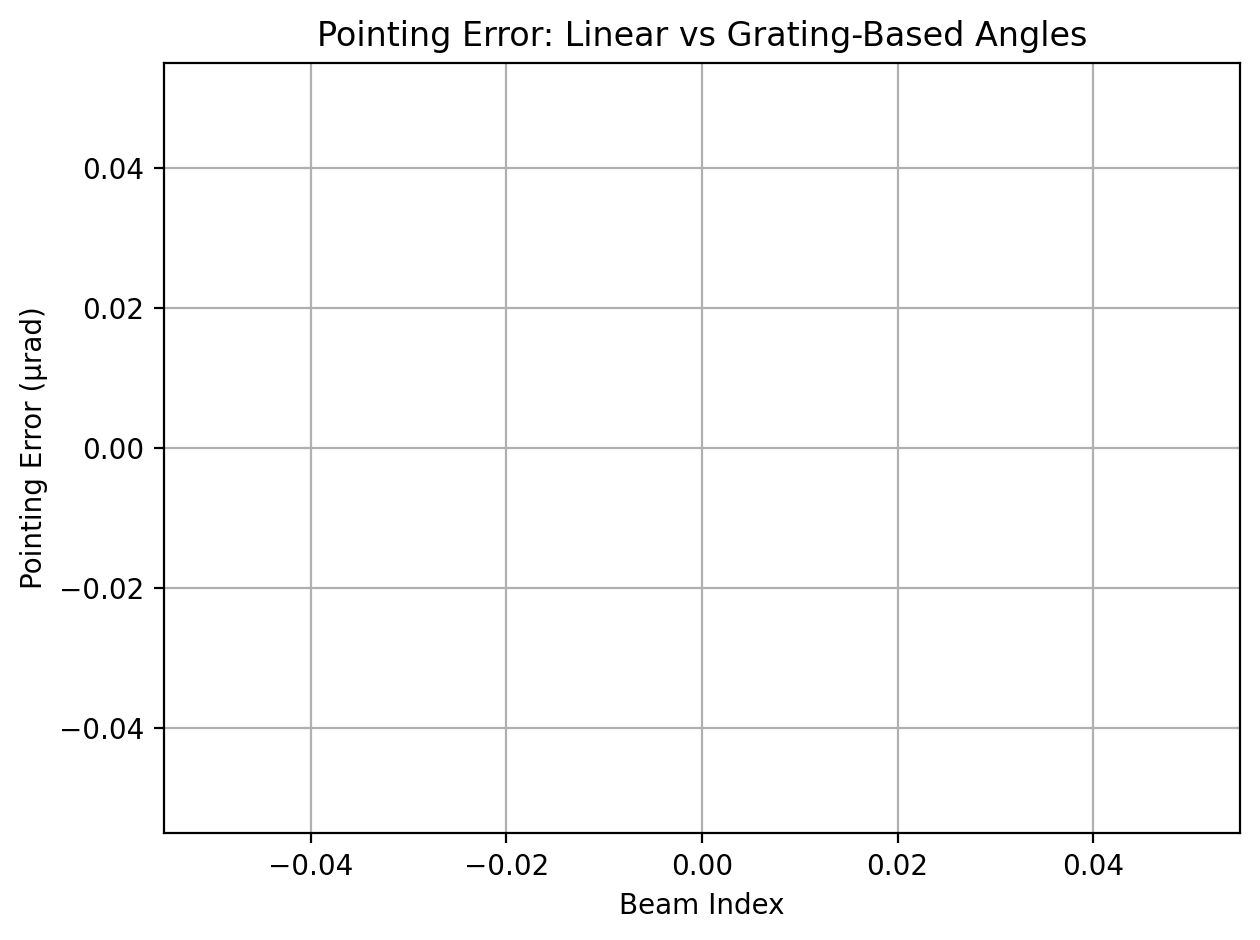

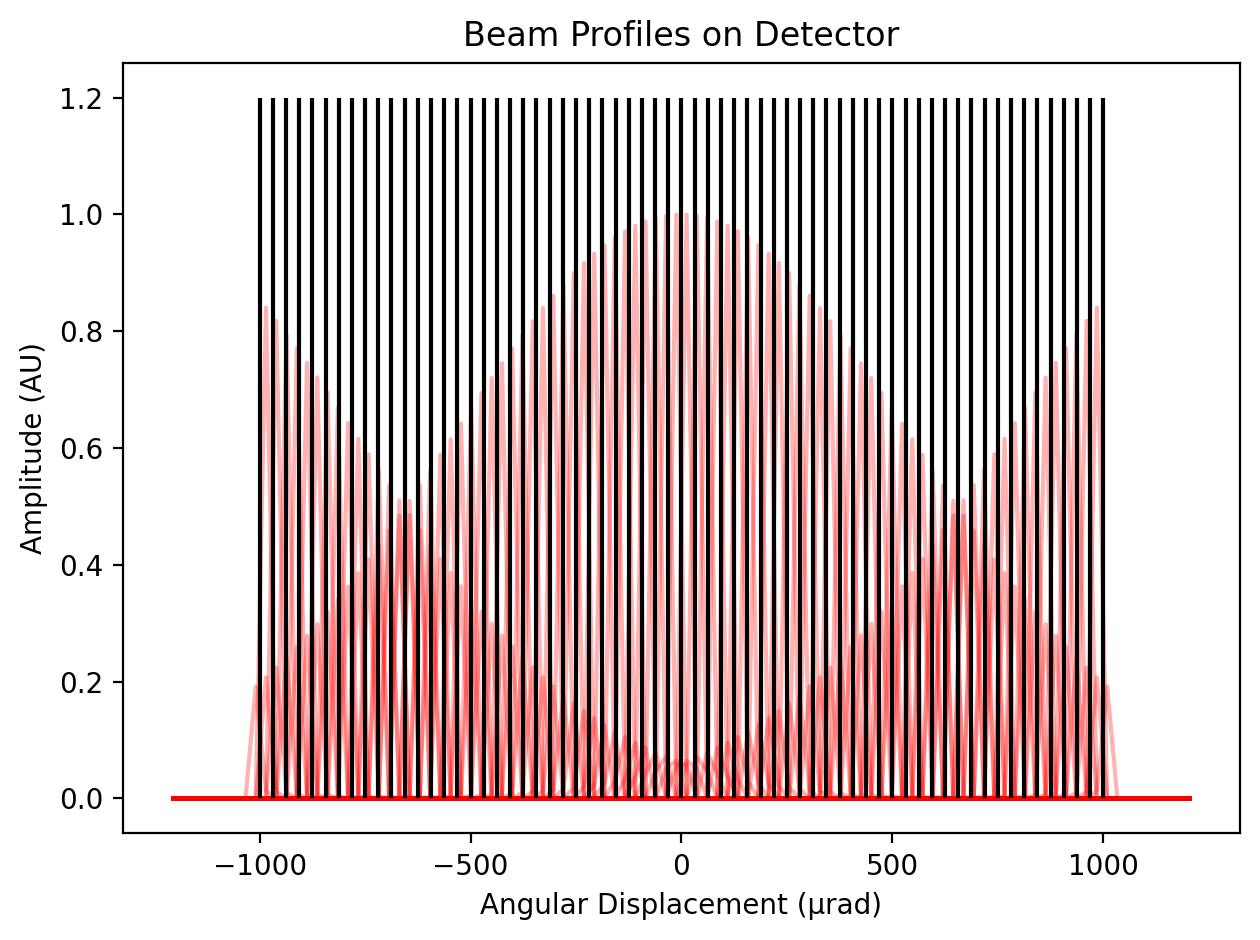

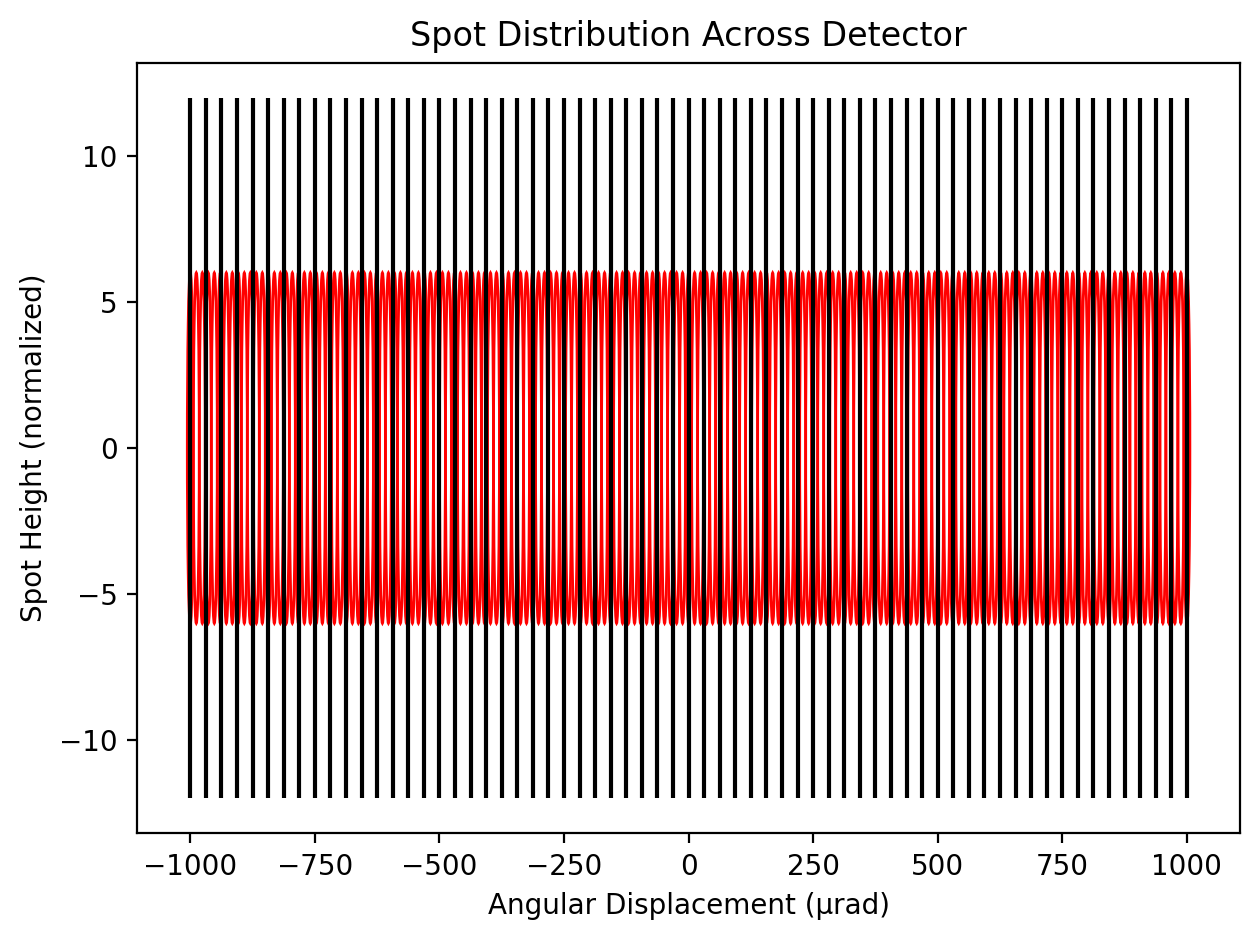

In [31]:
"""
Created on Mon Jun 30 16:14:14 2025

@author: gbclarke
@modified: DK Rai
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.constants import c


#  Computes geometric and optical parameters for the grating system
def _compute_geometry(lpmm, gsd, alt_km, swath_km, wl_nm, wl_span_nm):
    
    """
    Parameters:
    - lpmm: Lines per mm on the diffraction grating
    - gsd: Ground sampling distance (m)
    - alt_km: Altitude of the platform (km)
    - swath_km: Swath width on the ground (km)
    - wl_nm: Central wavelength (nm)
    - wl_span_nm: Total wavelength sweep range (nm)

    Returns:
    - fov_rad: Field of view in radians
    - line_spacing: Grating line spacing in meters
    - num_steps: Number of discrete angular beam steps
    - dwl: Wavelength step between ground spots
    - aoi_rad: Optimal angle of incidence on the grating (rad)
    - dispersion_mrad_nm: Angular dispersion in mrad/nm
    - bexpansion: Required beam expander ratio
    - div_urad: Far-field divergence in microradians
    - beam_out_mm: Output beam diameter in mm
    - beam_on_grating_mm: Beam footprint on the grating in mm
    """
    fov_rad = swath_km / alt_km                     # Field of view in rad
    line_spacing = 1 / (lpmm * 1000)                # Grating line spacing in m
    num_steps = int(np.ceil(swath_km * 1000 / gsd)) # Number of discrete angular beam steps. Also ceil outputs the higher number for the fraction, 166 without and 167 with ceil
    dwl = wl_span_nm / num_steps                    # Wavelength step between ground spots in nm

    # Sweep incident angles to find one that minimizes the diffraction error
    Number = 1000                                                # number of points between 0 and π/2.
    angles = np.linspace(0, np.pi / 2, Number)                   # points between 0 and π/2
    a1 = np.arcsin(wl_nm * 1e-9 / line_spacing - np.sin(angles)) # outputs deviation from first order diffraction condition, λ/d. Also true for tranmission geometry
    aoi_error = np.abs(a1 - angles)                              # gets absolute values of deviations
    min_index = np.argmin(aoi_error)                             # argmin returns minimum output
    aoi_rad = angles[min_index]                                  # Optimal angle of incidence on the grating in rad corresponding to minimum diffraction error

    # Dispersion calculated from angle difference per nm at optimal AOI
    a1_at_aoi = np.arcsin(wl_nm * 1e-9 / line_spacing - np.sin(aoi_rad))
    a2_at_aoi = np.arcsin((wl_nm + dwl) * 1e-9 / line_spacing - np.sin(aoi_rad))
    dispersion_mrad_nm = np.abs(a1_at_aoi - a2_at_aoi) * 1000 / dwl

    # Beam expansion required to map the angular dispersion to the field of view
    bexpansion = dispersion_mrad_nm * wl_span_nm / fov_rad / 1000

    # Beam divergence in far field (µrad)
    div_urad = gsd / 2.355 * 4 / (alt_km * 1000) * 1e6     # not sure what the 2.355 is for

    # Output beam diameter (diffraction-limited) and beam size at grating
    beam_out_mm = 2 * wl_nm * 1e-9 / (np.pi * div_urad / 2 * 1e-6) * 1e3
    beam_on_grating_mm = beam_out_mm / bexpansion

    return (fov_rad, line_spacing, num_steps, dwl, aoi_rad,
            dispersion_mrad_nm, bexpansion, div_urad, beam_out_mm,
            beam_on_grating_mm)

def _compute_pointing_error(num_steps, swath_km, alt_km, wl_nm, wl_span_nm,
                            line_spacing, aoi_rad, bexpansion):
    """
    Computes pointing error between linearly interpolated angles and
    those derived from grating frequency sweep.
    
    Returns:
    - angle_linear: Ideal pointing angle (linear scan)
    - wavelengths_nm: Wavelengths corresponding to beam steps
    - angle_grating: Real grating angles from wavelength sweep
    - pointing_error_urad: Error in angular pointing (µrad)
    """
    idx = np.arange(num_steps)
    angle_linear = idx / (num_steps - 1) * swath_km / alt_km

    # Define frequency sweep and convert to wavelength steps
    wl_start = wl_nm - wl_span_nm / 2
    wl_end = wl_nm + wl_span_nm / 2
    f_start = c / (wl_start * 1e-9)
    f_end = c / (wl_end * 1e-9)
    delta_f = (f_start - f_end) / (num_steps - 1)
    freqs = f_start - delta_f * idx
    wavelengths_nm = C / freqs * 1e9

    # Convert wavelengths to angles using grating equation
    a0 = np.arcsin(wavelengths_nm[0] * 1e-9 / line_spacing - np.sin(aoi_rad))
    angles = np.arcsin(wavelengths_nm * 1e-9 / line_spacing - np.sin(aoi_rad))
    angle_grating = -(a0 - angles) / bexpansion
    pointing_error_urad = (angle_linear - angle_grating) * 1e6

    return angle_linear, wavelengths_nm, angle_grating, pointing_error_urad

def plot_pointing_error(pointing_error_urad):
    """
    Plot the angular pointing error between ideal and grating-derived beams.
    """
    plt.figure(dpi=200)
    plt.plot(pointing_error_urad, 'm')
    plt.xlabel("Beam Index")
    plt.ylabel("Pointing Error (µrad)")
    plt.title("Pointing Error: Linear vs Grating-Based Angles")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_detector_response(angle_linear, angle_grating, div_urad,
                           swath_km, alt_km, n_pixels, num_steps):
    """
    Plot the Gaussian beam profiles from both linear and grating steps
    across the detector field.
    """
    plt.figure(dpi=200)
    x = np.linspace(angle_linear[0] - 10 * div_urad * 1e-6,
                    angle_linear[-1] + 10 * div_urad * 1e-6, 1000) * 1e6  # 

    for i in range(num_steps):
        g1 = np.exp(-2 * (x - angle_linear[i] * 1e6)**2 / (div_urad / 2)**2)
        g2 = np.exp(-2 * (x - angle_grating[i] * 1e6)**2 / (div_urad / 2)**2)
        plt.plot(x - swath_km / alt_km / 2 * 1e6, g1, 'r', alpha=0.3)
        plt.plot(x - swath_km / alt_km / 2 * 1e6, g2, 'b', alpha=0.3)

    # Add pixel edges
    pixel_edges = np.linspace(0, n_pixels - 2, n_pixels + 1) * swath_km / alt_km / (n_pixels - 2)
    plt.vlines(pixel_edges * 1e6 - swath_km / alt_km / 2 * 1e6, 0, 1.2, colors='k')
    plt.xlabel("Angular Displacement (µrad)")
    plt.ylabel("Amplitude (AU)")
    plt.title("Beam Profiles on Detector")
    plt.tight_layout()
    plt.show()

def plot_spot_distribution(angle_linear, angle_grating, gsd, alt_km,
                           swath_km, n_pixels, num_steps):
    """
    Show footprint (spots) of each beam on the angular domain.
    """
    fig, ax = plt.subplots(dpi=200)
    pixel_edges = np.linspace(0, n_pixels - 2, n_pixels + 1) * swath_km / alt_km / (n_pixels - 2)
    ax.vlines(pixel_edges * 1e6 - swath_km / alt_km / 2 * 1e6,
              -gsd / (alt_km / 1000), gsd / (alt_km / 1000), colors='k')

    for i in range(num_steps):
        for angle, color in [(angle_linear[i], 'r'), (angle_grating[i], 'b')]:
            ellipse = patches.Ellipse((angle * 1e6 - swath_km / alt_km / 2 * 1e6, 0),
                                      gsd / (alt_km / 1000), gsd / (alt_km / 1000),
                                      fill=False, edgecolor=color, linewidth=1)
            ax.add_patch(ellipse)

    ax.set_xlabel("Angular Displacement (µrad)")
    ax.set_ylabel("Spot Height (normalized)")
    ax.set_title("Spot Distribution Across Detector")
    plt.tight_layout()
    plt.show()

def setup_params(mode='Space'):
    """
    Define system parameters for either Space or Aircraft configuration.
    """
    return {
        'lpmm': 1500,
        'gsd': 6 if mode == 'Space' else 0.233,
        'h': 500 if mode == 'Space' else 4.5,
        'd': 1 if mode == 'Space' else 0.233 * (256 - 1) / 1000,
        'wl': 1040,
        'wl_span': 13.074,
        'n_pixels': 64 if mode == 'Space' else 8
    }

def run_grating_calc(params):
    """
    Main routine to compute geometry, pointing, and display results.
    """
    # Unpack parameters
    lpmm = params['lpmm']
    gsd = params['gsd']
    alt_km = params['h']
    swath_km = params['d']
    wl_nm = params['wl']
    wl_span_nm = params['wl_span']
    n_pixels = params['n_pixels']

    # Geometry calculations
    (fov_rad, line_spacing, num_steps, dwl, aoi_rad,
     dispersion_mrad_nm, bexpansion, div_urad, beam_out_mm,
     beam_on_grating_mm) = _compute_geometry(lpmm, gsd, alt_km, swath_km, wl_nm, wl_span_nm)

    # Pointing calculations
    (angle_linear, wavelengths_nm, angle_grating,
     pointing_error_urad) = _compute_pointing_error(num_steps, swath_km, alt_km, wl_nm, wl_span_nm,
                                                    line_spacing, aoi_rad, bexpansion)

    # Plot all results
    plot_pointing_error(pointing_error_urad)
    plot_detector_response(angle_linear, angle_grating, div_urad,
                           swath_km, alt_km, n_pixels, num_steps)
    plot_spot_distribution(angle_linear, angle_grating, gsd, alt_km,
                           swath_km, n_pixels, num_steps)
    
if __name__ == "__main__":
    params = setup_params('Space')  # Use 'Aircraft' for airborne mode and 'Space' for SC mode.
    run_grating_calc(params)

In [33]:
import numpy as np

def compute_etendue(diameter_m, fov_rad):
    """
    Calculate étendue for a circular aperture and small-angle FOV.

    Parameters:
    - diameter_m: aperture diameter in meters
    - fov_rad: full field of view in radians

    Returns:
    - A: aperture area in m²
    - Omega: solid angle in steradians
    - Etendue: in m²·sr
    """
    A = np.pi * (diameter_m / 2)**2
    Omega = np.pi * (fov_rad / 2)**2  # for small angles
    etendue = A * Omega
    return A, Omega, etendue

# Parameters
diameter_m = 0.60  # 60 cm
fov_urad = 20       # 20 µrad
fov_rad = fov_urad * 1e-6  # convert to radians

# Compute
A, Omega, E = compute_etendue(diameter_m, fov_rad)

# Output
print(f"Aperture Area (A): {A:.6e} m²")
print(f"Solid Angle (Ω): {Omega:.6e} sr")
print(f"Étendue (E): {E:.6e} m²·sr")


Aperture Area (A): 2.827433e-01 m²
Solid Angle (Ω): 3.141593e-10 sr
Étendue (E): 8.882644e-11 m²·sr


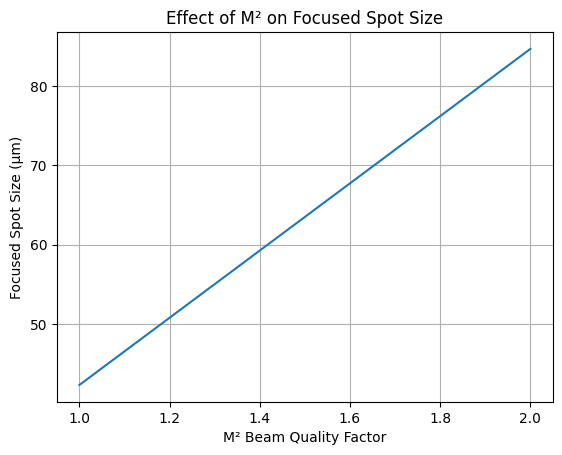

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def focused_spot_size(M2, wavelength, focal_length, input_waist):
    return M2 * wavelength * focal_length / (np.pi * input_waist)

# Parameters
wavelength = 1.064e-6  # 1064 nm (YAG)
focal_length = 0.125   # 12.5 cm
input_waist = 1e-3     # 1 mm

M2_values = np.linspace(1, 2, 10)
spot_sizes = focused_spot_size(M2_values, wavelength, focal_length, input_waist)

plt.plot(M2_values, spot_sizes * 1e6)
plt.xlabel("M² Beam Quality Factor")
plt.ylabel("Focused Spot Size (µm)")
plt.title("Effect of M² on Focused Spot Size")
plt.grid(True)
plt.show()

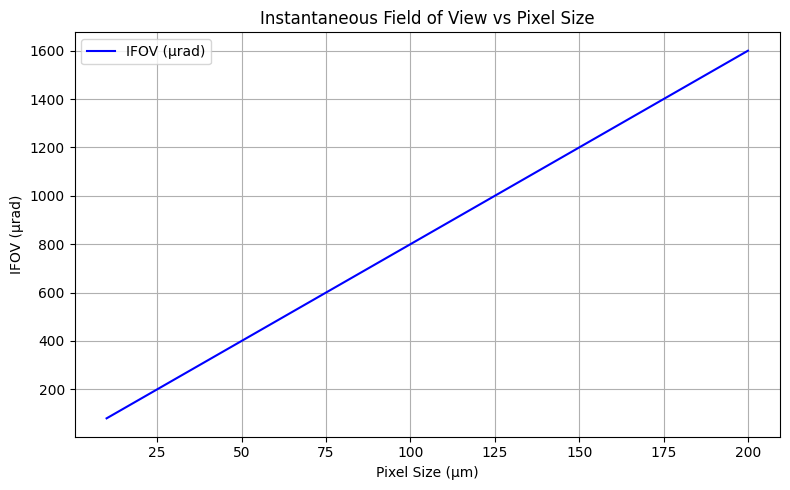

For a 64 µm pixel:
  IFOV           = 512.00 µrad
  Solid angle    = 2.06e-07 sr
  Aperture area  = 2.83e-01 m²
  Étendue        = 5.82e-08 m²·sr
  Ground footprint at 500 km = 256.00 m


In [36]:
import numpy as np
import matplotlib.pyplot as plt

def compute_ifov_and_etendue(pixel_size_um, focal_length_cm, aperture_diameter_cm, altitude_km):
    # Convert units to SI
    d = pixel_size_um * 1e-6         # pixel size in meters
    f = focal_length_cm * 1e-2       # focal length in meters
    D = aperture_diameter_cm * 1e-2  # aperture diameter in meters
    h = altitude_km * 1e3            # altitude in meters

    # IFOV (radians)
    ifov = d / f  # small-angle approximation

    # Solid angle (sr)
    omega = np.pi * (ifov / 2)**2

    # Aperture area (m²)
    A = np.pi * (D / 2)**2

    # Étendue
    etendue = A * omega

    # Ground footprint diameter (m)
    footprint = h * ifov  # linear approximation

    return ifov, omega, A, etendue, footprint

# Fixed parameters
focal_length_cm = 12.5
aperture_diameter_cm = 60
altitude_km = 500

# Sweep over pixel sizes
pixel_sizes_um = np.linspace(10, 200, 100)
ifov_urad = []
footprints_m = []

for pixel_size_um in pixel_sizes_um:
    ifov, _, _, _, footprint = compute_ifov_and_etendue(
        pixel_size_um, focal_length_cm, aperture_diameter_cm, altitude_km
    )
    ifov_urad.append(ifov * 1e6)
    footprints_m.append(footprint)

# Plot: IFOV vs Pixel Size
plt.figure(figsize=(8, 5))
plt.plot(pixel_sizes_um, ifov_urad, label='IFOV (µrad)', color='blue')
plt.xlabel("Pixel Size (µm)")
plt.ylabel("IFOV (µrad)")
plt.title("Instantaneous Field of View vs Pixel Size")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: Show ground footprint for 64 µm pixel
pixel_size_test = 64
ifov, omega, A, etendue, footprint = compute_ifov_and_etendue(
    pixel_size_test, focal_length_cm, aperture_diameter_cm, altitude_km
)

print(f"For a {pixel_size_test} µm pixel:")
print(f"  IFOV           = {ifov * 1e6:.2f} µrad")
print(f"  Solid angle    = {omega:.2e} sr")
print(f"  Aperture area  = {A:.2e} m²")
print(f"  Étendue        = {etendue:.2e} m²·sr")
print(f"  Ground footprint at {altitude_km} km = {footprint:.2f} m")


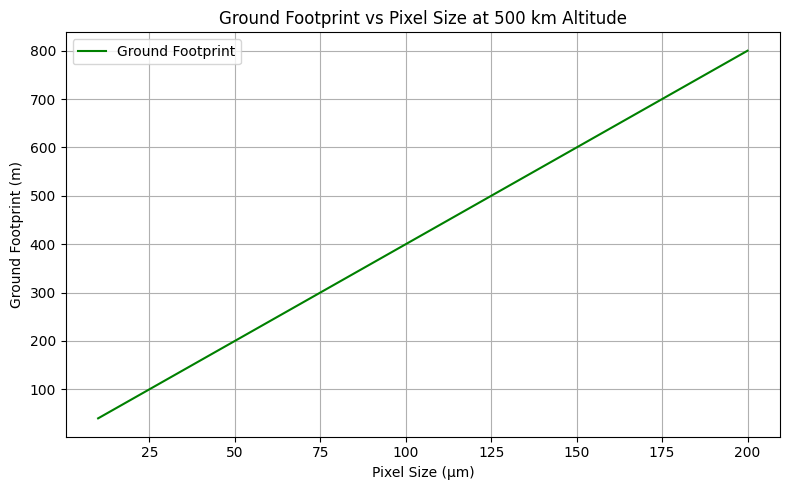

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def compute_ground_footprint(pixel_size_um, focal_length_cm, altitude_km):
    d = pixel_size_um * 1e-6       # pixel size in meters
    f = focal_length_cm * 1e-2     # focal length in meters
    h = altitude_km * 1e3          # altitude in meters
    ifov = d / f                   # IFOV in radians
    footprint = h * ifov           # Ground footprint in meters
    return footprint

# Parameters
focal_length_cm = 12.5
altitude_km = 500

# Sweep pixel sizes
pixel_sizes_um = np.linspace(10, 200, 100)
footprints_m = [compute_ground_footprint(d, focal_length_cm, altitude_km) for d in pixel_sizes_um]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(pixel_sizes_um, footprints_m, label='Ground Footprint', color='green')
plt.xlabel("Pixel Size (µm)")
plt.ylabel("Ground Footprint (m)")
plt.title("Ground Footprint vs Pixel Size at 500 km Altitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [38]:
import numpy as np
import matplotlib.pyplot as plt

def compute_array_footprint(pixel_size_um, focal_length_cm, altitude_km, Nx, Ny):
    d = pixel_size_um * 1e-6       # pixel size (m)
    f = focal_length_cm * 1e-2     # focal length (m)
    h = altitude_km * 1e3          # altitude (m)

    ifov = d / f                   # radians
    gsd = h * ifov                 # ground sampling distance (m)
    swath = Ny * gsd               # cross-track swath width (m)
    along_track = Nx * gsd        # along-track extent (frame length)
    
    return gsd, swath, along_track

# Detector and system parameters
pixel_size_um = 64
focal_length_cm = 12.5
altitude_km = 500
Nx = 1024   # along-track pixels (e.g., pushbroom line scanner)
Ny = 2048   # cross-track pixels

# Compute
gsd, swath, track_length = compute_array_footprint(pixel_size_um, focal_length_cm, altitude_km, Nx, Ny)

# Print results
print(f"Pixel Size          : {pixel_size_um} µm")
print(f"Focal Length        : {focal_length_cm} cm")
print(f"Altitude            : {altitude_km} km")
print(f"Array Size (Nx x Ny): {Nx} x {Ny}")
print(f"GSD per pixel       : {gsd:.2f} m")
print(f"Swath Width         : {swath/1000:.2f} km")
print(f"Frame Length (Along-track): {track_length/1000:.2f} km")


Pixel Size          : 64 µm
Focal Length        : 12.5 cm
Altitude            : 500 km
Array Size (Nx x Ny): 1024 x 2048
GSD per pixel       : 256.00 m
Swath Width         : 524.29 km
Frame Length (Along-track): 262.14 km


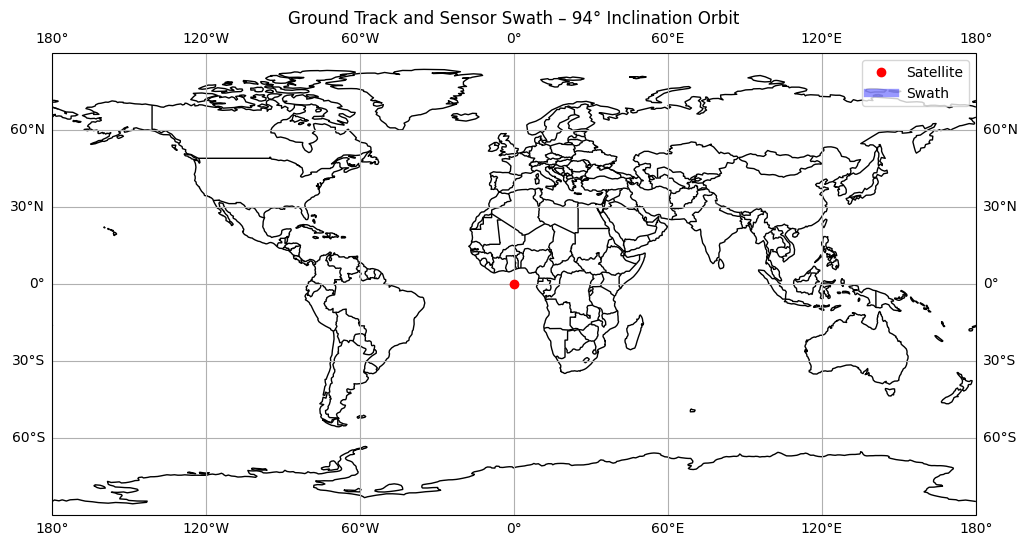

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.animation import FuncAnimation

# Earth and orbit constants
Re = 6371  # Earth radius (km)
alt_km = 500  # Altitude
r_orbit = Re + alt_km
inclination_deg = 94
fov_rad = 20e-6

# Ground swath width
swath_half_width_km = r_orbit * fov_rad / 2
swath_deg = (2 * swath_half_width_km / Re) * (180 / np.pi)

# Orbit path: simulate retrograde polar orbit
n_frames = 180
theta = np.linspace(0, 2 * np.pi, n_frames)
incl = np.radians(inclination_deg)

lat = np.degrees(np.arcsin(np.sin(incl) * np.sin(theta)))
lon = (np.degrees(theta * 15) - 180) % 360 - 180  # simulate ground drift

# Set up plot
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.gridlines(draw_labels=True)

# Plot handles
sat_dot, = ax.plot([], [], 'ro', label='Satellite')
swath_line, = ax.plot([], [], 'b-', lw=6, alpha=0.4, label='Swath')

# Update function
def update(frame):
    current_lon = lon[frame]
    current_lat = lat[frame]

    sat_dot.set_data([current_lon], [current_lat])

    # Swath edges (assume line along longitude at constant latitude)
    swath_lons = [current_lon - swath_deg / 2, current_lon + swath_deg / 2]
    swath_lats = [current_lat, current_lat]
    swath_line.set_data(swath_lons, swath_lats)

    return sat_dot, swath_line

# Animate
anim = FuncAnimation(fig, update, frames=n_frames, interval=100, blit=True)

plt.legend()
plt.title("Ground Track and Sensor Swath – 94° Inclination Orbit")
plt.show()
